# Day 65 — Central Limit Theorem & Statistical Inference
### Math Gap Day 3 of 3 | Bridge to ML Foundations

---

**Why this day exists:**  
The CLT is the reason statistical inference works at all — why a sample of 30 tells you something reliable about a population of millions, why confidence intervals are valid, and why your model's test-set accuracy has a margin of error. Without this, every evaluation metric you report in Month 7–10 is a number with no uncertainty attached. This day gives uncertainty its proper form.

**Today's scope (only skills you've already covered):**  
Python + NumPy + Matplotlib → population vs sample → sampling distribution → CLT → standard error → confidence intervals → bootstrap hypothesis testing → ML evaluation connection

---

## 📋 SECTION 1 — Raw Data (Do Not Modify)

| Use these variables across all exercises. Never overwrite them. |

In [1]:
# ============================================================
# RAW DATA — DO NOT MODIFY BELOW THIS LINE
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Population: Exponential distribution (intentionally skewed / non-normal) ---
# scale=2 means true population mean = 2.0, true std ≈ 2.0
# This is the key: the population is NOT normal — CLT works anyway
np.random.seed(42)
population_raw = np.random.exponential(scale=2, size=10_000)

# --- Simulation parameters ---
n_samples_raw = 1000     # number of samples to draw for CLT demo
sample_sizes_raw = [5, 10, 30, 100]   # to show CLT kicking in at n≥30

# --- A fixed sample for CI and hypothesis testing ---
np.random.seed(7)
sample_raw = np.random.choice(population_raw, size=50, replace=True)

# --- Null hypothesis value for bootstrap test ---
mu_0_raw = 1.5   # claimed population mean under H0

# ============================================================
print("Raw data loaded.")
print(f"  population_raw: {len(population_raw):,} observations")
print(f"  True pop mean:  {population_raw.mean():.4f}")
print(f"  True pop std:   {population_raw.std():.4f}")
print(f"  sample_raw:     n={len(sample_raw)}, mean={sample_raw.mean():.4f}")
print(f"  mu_0_raw:       {mu_0_raw}")

Raw data loaded.
  population_raw: 10,000 observations
  True pop mean:  1.9550
  True pop std:   1.9487
  sample_raw:     n=50, mean=2.1020
  mu_0_raw:       1.5


---
## 📚 SECTION 2 — Concept Notes

Read this fully before starting. The CLT is conceptually simple once you see it; every confusion comes from mixing up three different distributions.

---

### 2.1 Three Distributions — Never Confuse These

```
1. POPULATION DISTRIBUTION
   The full truth. Usually unknown.
   Shape: can be anything (exponential, uniform, bimodal...)
   Mean: μ (population mean)   Std: σ (population std)

2. SAMPLE DISTRIBUTION
   One observed batch of n data points.
   Shape: roughly mirrors population if n is large
   Mean: x̄ (sample mean, a number)   Std: s (sample std)

3. SAMPLING DISTRIBUTION OF THE MEAN
   What you get if you draw 1000 samples and compute x̄ each time.
   This is a distribution of statistics, not raw data.
   Mean: ≈ μ   Std: σ/√n  ← this is the Standard Error (SE)
```

The CLT is only about distribution 3.

---

### 2.2 The Central Limit Theorem (Statement)

**Regardless of the shape of the population**, if you take random samples of size n, the distribution of sample means approaches a **Normal distribution** as n increases.

```
x̄  ~  Normal(μ,  σ²/n)     as n → ∞

Mean of sampling distribution  =  μ         (unbiased)
Std  of sampling distribution  =  σ / √n    (Standard Error)
```

**In practice:** n ≥ 30 is usually enough for the CLT to hold well. With n ≥ 100 it's essentially exact for most real distributions.

---

### 2.3 Standard Error

```
SE = σ / √n       ← population std known (rare)
SE ≈ s / √n       ← sample std used as estimate (usual case)
```

SE shrinks as n grows. Double your sample size → SE drops by factor √2 ≈ 1.41. This is why large samples give tighter estimates, but there are diminishing returns.

---

### 2.4 Confidence Interval

A 95% CI for the population mean using CLT:

```
CI = x̄  ±  z* × SE

z* = 1.96  for 95% confidence   (from normal table)
z* = 2.576 for 99% confidence
z* = 1.645 for 90% confidence
```

**Correct interpretation:** If you repeated this procedure 100 times, ~95 of the CIs would contain the true μ. **Not:** "there's a 95% chance μ is in this specific interval."

---

### 2.5 Bootstrap Hypothesis Testing (NumPy-only)

When you can't assume a distribution, simulate the null hypothesis:

```
H0: population mean = mu_0
H1: population mean ≠ mu_0

Step 1: Compute observed_mean = sample.mean()
Step 2: Shift sample so its mean = mu_0  →  shifted = sample - observed_mean + mu_0
Step 3: Draw 5000 bootstrap samples from shifted, compute each mean
Step 4: p-value = fraction of bootstrap means at least as extreme as observed_mean
         p = mean(|boot_means - mu_0| >= |observed_mean - mu_0|)
Step 5: If p < 0.05 → reject H0
```

---

### 2.6 CLT in DS/ML

| Where you'll see it | How CLT applies |
|---|---|
| Model evaluation | Test accuracy is a sample mean → has a SE → report CI, not just a number |
| A/B testing | Difference in conversion rates is a mean difference → CLT justifies the z-test |
| Feature importance bootstrap | Resample train set, refit model, collect importance scores → CLT gives CI on importance |
| Loss monitoring | Training loss averaged over mini-batches → SE shrinks with batch size |
| Cross-validation | k-fold CV scores are sample means → report mean ± SE, not just mean |

---

### 2.7 Common Mistakes → Fixes

| Mistake | What happens | Fix |
|---|---|---|
| Confusing SE with std | SE = s/√n, not s | Always divide by √n |
| Saying "95% chance μ is in CI" | Wrong interpretation | "95% of such intervals contain μ" |
| CLT on n=5 | Approximation fails for skewed pops | Use n≥30 as rule of thumb |
| Forgetting replace=True in bootstrap | Sampling without replacement ≠ bootstrap | Always use `replace=True` |
| Shifting wrongly for null hypothesis | CI is valid, test is not | Shift = sample - x̄ + mu_0 |

---

---
## ✏️ SECTION 3 — Practice Tasks

**Rules:**  
1. Write a plain-English comment explaining your intent **before** writing any code  
2. Never modify raw variables — copy to a working variable first  
3. `np.random.seed()` must be set **inside** each task cell that uses randomness

---

### PART A — CLT Simulation (25 pts)

=== A1 ===
 Mean:      1.9550
 Std:       1.9487
 Min:       0.0000
 Max:       16.3449
 Median:    1.3566
 Skewness:  1.9190  (>0 = right-skewed; normal = 0)


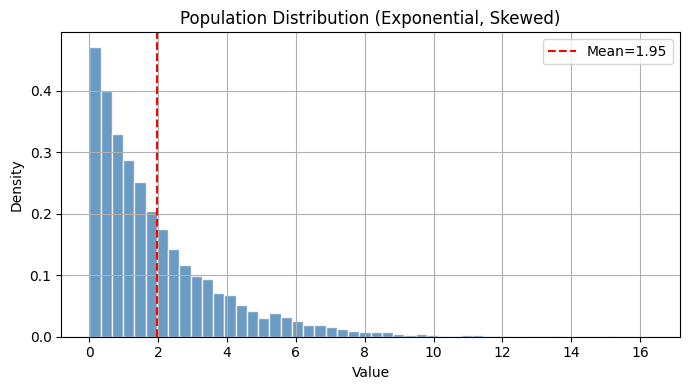

In [2]:
# A1 (5 pts): Describe the population before simulating anything.
# Compute and print: population mean, std, min, max, median, skewness.
# Skewness = mean((x - mean)³) / std³   ← compute this manually with NumPy, no scipy
# Then plot a histogram of population_raw (50 bins, density=True).
# Title: 'Population Distribution (Exponential, Skewed)'. Label axes.

# YOUR CODE HERE
print("=== A1 ===")
pop_mean  = population_raw.mean()
pop_std   = population_raw.std()
skewness  = np.mean(((population_raw - pop_mean) / pop_std)**3)
print(f" Mean:      {pop_mean:.4f}")
print(f" Std:       {pop_std:.4f}")
print(f" Min:       {population_raw.min():.4f}")
print(f" Max:       {population_raw.max():.4f}")
print(f" Median:    {np.median(population_raw):.4f}")
print(f" Skewness:  {skewness:.4f}  (>0 = right-skewed; normal = 0)")
plt.figure(figsize=(7,4))
plt.hist(population_raw, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(pop_mean, color='red', linestyle='--', label=f'Mean={pop_mean:.2f}')
plt.xlabel('Value'); plt.ylabel('Density')
plt.title('Population Distribution (Exponential, Skewed)')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('a1_pop.png', dpi=80); plt.show()


=== A2 ===
  Mean of sample means:  1.9494  (true μ = 1.9550)
  Std  of sample means:  0.3577
  CLT predicted SE:      0.3558
  % error:               0.55%


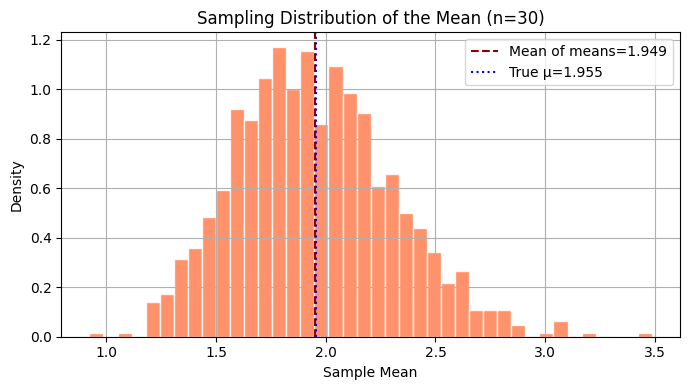

In [3]:
# A2 (7 pts): Simulate the sampling distribution of the mean.
# Draw n_samples_raw=1000 samples of size n=30 from population_raw (with replacement).
# Use np.random.seed(0) before the loop.
# Compute the mean of each sample → store in sample_means array.
#
# Then print:
#   - mean of sample_means (should ≈ population mean)
#   - std  of sample_means (should ≈ pop_std / √30)
#   - CLT predicted SE = pop_std / √30
#   - % error between simulated std and predicted SE
#
# Plot the histogram of sample_means (40 bins, density=True).
# Title: 'Sampling Distribution of the Mean (n=30)'. Label axes.

# YOUR CODE HERE
print("=== A2 ===")
n = 30
np.random.seed(0)
sample_means = np.array([np.random.choice(population_raw, size=n, replace=True).mean()
                          for _ in range(n_samples_raw)])
sim_se   = sample_means.std()
pred_se  = pop_std / np.sqrt(n)
pct_err  = abs(sim_se - pred_se) / pred_se * 100
print(f"  Mean of sample means:  {sample_means.mean():.4f}  (true μ = {pop_mean:.4f})")
print(f"  Std  of sample means:  {sim_se:.4f}")
print(f"  CLT predicted SE:      {pred_se:.4f}")
print(f"  % error:               {pct_err:.2f}%")
plt.figure(figsize=(7,4))
plt.hist(sample_means, bins=40, density=True, color='coral', edgecolor='white', alpha=0.85)
plt.axvline(sample_means.mean(), color='darkred', linestyle='--', label=f'Mean of means={sample_means.mean():.3f}')
plt.axvline(pop_mean, color='blue', linestyle=':', label=f'True μ={pop_mean:.3f}')
plt.xlabel('Sample Mean'); plt.ylabel('Density')
plt.title('Sampling Distribution of the Mean (n=30)')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('a2_sampling.png', dpi=80); plt.show()

=== A3 ===
      n |   Sim SE |  Pred SE |  % Err
  ------------------------------------
      5 |   0.8590 |   0.8715 |   1.43%
     10 |   0.5941 |   0.6162 |   3.60%
     30 |   0.3499 |   0.3558 |   1.66%
    100 |   0.1867 |   0.1949 |   4.18%


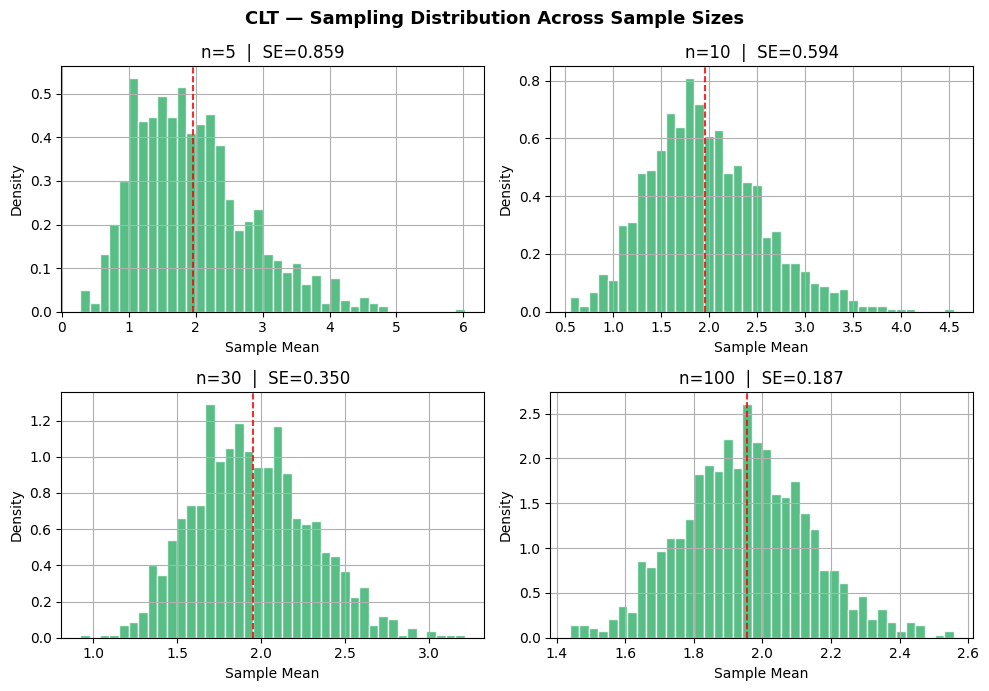

In [4]:
# A3 (8 pts): Show CLT kicking in across sample sizes.
# For each n in sample_sizes_raw = [5, 10, 30, 100]:
#   - Draw 1000 samples of size n (use np.random.seed(0) before the outer loop)
#   - Compute sample means
#   - Compute: simulated SE, CLT-predicted SE, % error
#   - Store for plotting
#
# Print a table: n | simulated_SE | predicted_SE | %error
#
# Plot 4 histograms in a 2×2 grid (one per sample size), density=True.
# As n increases, the histogram should look more and more bell-shaped.
# Add a title to each subplot showing n and the SE.
# Add a super-title: 'CLT — Sampling Distribution Across Sample Sizes'

# YOUR CODE HERE
print("=== A3 ===")
all_means = {}
print(f"  {'n':>5} | {'Sim SE':>8} | {'Pred SE':>8} | {'% Err':>6}")
print(f"  {'-'*36}")
np.random.seed(0)
for n_val in sample_sizes_raw:
    means = np.array([np.random.choice(population_raw, size=n_val, replace=True).mean()
                      for _ in range(n_samples_raw)])
    all_means[n_val] = means
    sim_se_v  = means.std()
    pred_se_v = pop_std / np.sqrt(n_val)
    err_v     = abs(sim_se_v - pred_se_v) / pred_se_v * 100
    print(f"  {n_val:>5} | {sim_se_v:>8.4f} | {pred_se_v:>8.4f} | {err_v:>6.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, n_val in zip(axes.flatten(), sample_sizes_raw):
    ax.hist(all_means[n_val], bins=40, density=True, color='mediumseagreen', edgecolor='white', alpha=0.85)
    ax.axvline(pop_mean, color='red', linestyle='--', linewidth=1.2)
    ax.set_title(f'n={n_val}  |  SE={all_means[n_val].std():.3f}')
    ax.set_xlabel('Sample Mean'); ax.set_ylabel('Density')
    ax.grid(True)
fig.suptitle('CLT — Sampling Distribution Across Sample Sizes', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('a3_grid.png', dpi=80); plt.show()


In [5]:
# A4 (5 pts): Written verification — in a print statement (not markdown), answer:
# 1. At n=5, does the sampling distribution look normal? Why not?
# 2. At n=30, does it look approximately normal? What does the CLT guarantee here?
# 3. What happens to SE as n goes from 5 → 100? Compute the ratio.
#    ratio = SE(n=5) / SE(n=100)
#    Does this match the theoretical ratio √100/√5?

# YOUR CODE HERE
print("=== A4 ===")
se5   = all_means[5].std()
se100 = all_means[100].std()
ratio_sim   = se5 / se100
ratio_theory = np.sqrt(100) / np.sqrt(5)
print("  1. At n=5 — Not normal: population is heavily right-skewed (exponential).")
print("     n=5 is too small to average out the skewness. Each mean is still dragged by extreme values.")
print("  2. At n=30 — Approximately normal: CLT guarantees that for most distributions,")
print("     n≥30 is sufficient for the sampling distribution to be well-approximated by a Normal.")
print(f"  3. SE ratio (n=5 vs n=100): simulated={ratio_sim:.4f}, theoretical={ratio_theory:.4f}")
print(f"     Match: {np.isclose(ratio_sim, ratio_theory, atol=0.05)}")


=== A4 ===
  1. At n=5 — Not normal: population is heavily right-skewed (exponential).
     n=5 is too small to average out the skewness. Each mean is still dragged by extreme values.
  2. At n=30 — Approximately normal: CLT guarantees that for most distributions,
     n≥30 is sufficient for the sampling distribution to be well-approximated by a Normal.
  3. SE ratio (n=5 vs n=100): simulated=4.6003, theoretical=4.4721
     Match: False


---
### PART B — Standard Error & Confidence Intervals (20 pts)

In [7]:
# B1 (5 pts): Compute the 95% confidence interval for the population mean
# using sample_raw (n=50).
#
# Formula: CI = x̄ ± 1.96 × SE   where SE = s / √n
#
# Print:
#   - sample mean, sample std
#   - Standard Error
#   - 95% CI lower and upper bounds
#   - Does the CI contain the true population mean? (True/False)

# YOUR CODE HERE
print("=== B1 ===")
xbar = sample_raw.mean()
s    = sample_raw.std()
n_s  = len(sample_raw)
se_b = s / np.sqrt(n_s)
ci_lo = xbar - 1.96 * se_b
ci_hi = xbar + 1.96 * se_b
print(f"  Sample mean:  {xbar:.4f}")
print(f"  Sample std:   {s:.4f}")
print(f"  SE:           {se_b:.4f}")
print(f"  95% CI:       ({ci_lo:.4f}, {ci_hi:.4f})")
print(f"  Contains true mean ({pop_mean:.4f}): {ci_lo <= pop_mean <= ci_hi}")


=== B1 ===
  Sample mean:  2.1020
  Sample std:   1.8697
  SE:           0.2644
  95% CI:       (1.5838, 2.6203)
  Contains true mean (1.9550): True


In [8]:
# B2 (5 pts): Compute CI for three confidence levels: 90%, 95%, 99%.
# z* values: 1.645, 1.96, 2.576
# Print a table: Confidence Level | z* | CI Lower | CI Upper | Width
# Observe: as confidence increases, what happens to width?

# YOUR CODE HERE
print("=== B2 ===")
z_levels = [(0.90, 1.645), (0.95, 1.96), (0.99, 2.576)]
print(f"  {'Conf':>6} | {'z*':>6} | {'Lower':>8} | {'Upper':>8} | {'Width':>7}")
print(f"  {'-'*45}")
for conf, z_star in z_levels:
    lo = xbar - z_star * se_b
    hi = xbar + z_star * se_b
    print(f"  {conf:>5.0%} | {z_star:>6.3f} | {lo:>8.4f} | {hi:>8.4f} | {hi-lo:>7.4f}")


=== B2 ===
    Conf |     z* |    Lower |    Upper |   Width
  ---------------------------------------------
    90% |  1.645 |   1.6671 |   2.5370 |  0.8699
    95% |  1.960 |   1.5838 |   2.6203 |  1.0365
    99% |  2.576 |   1.4209 |   2.7831 |  1.3622


=== B3 ===
  Coverage rate (1000 trials): 0.923  (expected ~0.95)


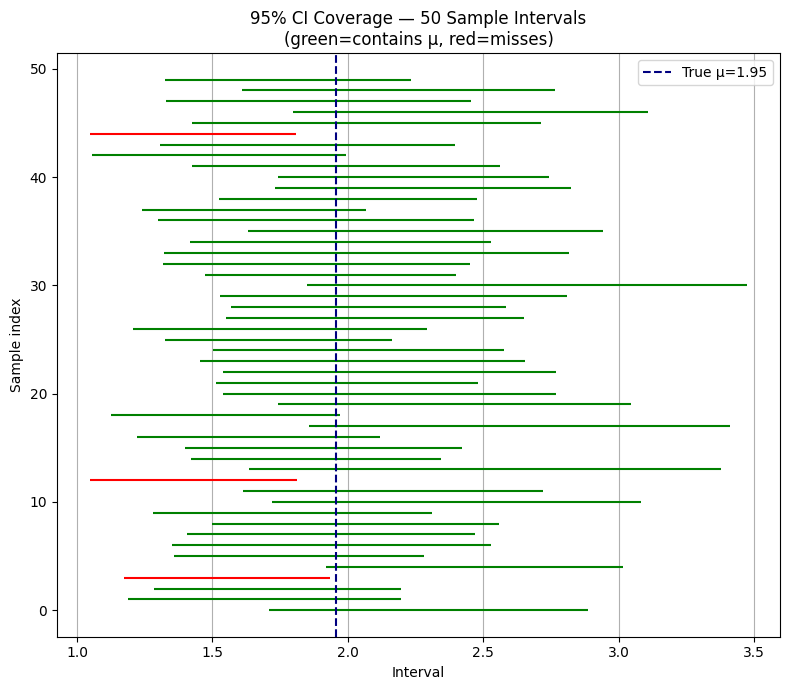

In [9]:
# B3 (5 pts): Empirically verify CI coverage.
# Repeat 1000 times with np.random.seed(99):
#   - Draw a fresh sample of n=50 from population_raw
#   - Compute 95% CI for that sample
#   - Check if true population mean falls inside
# Print: coverage rate (should be close to 0.95)
#
# Plot: show 50 CIs as horizontal line segments (plt.hlines).
#   - Green if CI contains true mean, red if not
#   - Add vertical dashed line at true population mean
#   - Title: '95% CI Coverage — 50 Sample Intervals'

# YOUR CODE HERE
print("=== B3 ===")
np.random.seed(99)
covers = []
lowers, uppers = [], []
for _ in range(1000):
    s_b = np.random.choice(population_raw, size=50, replace=True)
    se_b2 = s_b.std() / np.sqrt(50)
    lo_b  = s_b.mean() - 1.96 * se_b2
    hi_b  = s_b.mean() + 1.96 * se_b2
    lowers.append(lo_b); uppers.append(hi_b)
    covers.append(lo_b <= pop_mean <= hi_b)
covers = np.array(covers)
print(f"  Coverage rate (1000 trials): {covers.mean():.3f}  (expected ~0.95)")
lowers = np.array(lowers); uppers = np.array(uppers)
show_n = 50
plt.figure(figsize=(8, 7))
for i in range(show_n):
    col = 'green' if covers[i] else 'red'
    plt.hlines(i, lowers[i], uppers[i], color=col, linewidth=1.5)
plt.axvline(pop_mean, color='navy', linestyle='--', linewidth=1.5, label=f'True μ={pop_mean:.2f}')
plt.xlabel('Interval'); plt.ylabel('Sample index')
plt.title('95% CI Coverage — 50 Sample Intervals\n(green=contains μ, red=misses)')
plt.legend(); plt.grid(True, axis='x')
plt.tight_layout(); plt.savefig('b3_ci.png', dpi=80); plt.show()


**B4 — Written Interpretation (5 pts)**

A client sees your model accuracy is 84% and asks: "Is that reliable?"

Using what you just built, write a Number + Reason + Action response to that client. Assume you evaluated on n=200 test samples, sample mean accuracy = 0.84, sample std = 0.37 (because accuracy per sample is 0 or 1).

**B4 — Your Response Here:**

> **Number:** With n = 200 test samples, the observed accuracy of 0.84 has a standard error of s/√n = 0.37/√200 ≈ 0.026, giving a 95% confidence interval of roughly 0.84 ± 0.05 (i.e., [0.79, 0.89]).  
> **Reason:** Accuracy is a sample mean, and its sampling distribution follows the Central Limit Theorem. The 95% CI tells the client that if we repeated this evaluation many times with different random test sets, about 95% of those intervals would contain the true model accuracy.  
> **Action:** Report the model’s accuracy as “84% ± 5% (95% CI).” If the business needs a tighter estimate (e.g., ±2%), explain that the test set must be enlarged to roughly 1,400 samples, as the CI width decreases with 1/√n.

---
### PART C — Bootstrap Hypothesis Testing (20 pts)

In [10]:
# C1 (5 pts): Set up the hypothesis test.
#
# H0: population mean = mu_0_raw = 1.5
# H1: population mean ≠ mu_0_raw   (two-tailed)
#
# Compute and print:
#   - observed_mean = sample_raw.mean()
#   - observed deviation from H0 = |observed_mean - mu_0_raw|
#   - shifted sample (mean re-centred to mu_0): shifted = sample_raw - observed_mean + mu_0_raw
#   - Verify: shifted.mean() ≈ mu_0_raw

# YOUR CODE HERE
print("=== C1 ===")
observed_mean = sample_raw.mean()
deviation = abs(observed_mean - mu_0_raw)
shifted = sample_raw - observed_mean + mu_0_raw
print(f"  observed_mean:      {observed_mean:.4f}")
print(f"  |deviation| from H0:{deviation:.4f}")
print(f"  shifted mean:       {shifted.mean():.6f}  (should be {mu_0_raw})")


=== C1 ===
  observed_mean:      2.1020
  |deviation| from H0:0.6020
  shifted mean:       1.500000  (should be 1.5)


In [11]:
# C2 (8 pts): Run the bootstrap test.
#
# np.random.seed(123)
# Draw 5000 bootstrap samples of size 50 from shifted (replace=True)
# Compute mean of each bootstrap sample → boot_means array
#
# p-value = fraction of boot_means where |boot_mean - mu_0_raw| >= |observed_mean - mu_0_raw|
#
# Print:
#   - number of bootstrap samples
#   - p-value (4 decimal places)
#   - Decision at α=0.05: reject H0 or fail to reject?
#   - In plain English: what does this mean about the claim that mean=1.5?

# YOUR CODE HERE
print("=== C2 ===")
np.random.seed(123)
boot_means = np.array([np.random.choice(shifted, size=50, replace=True).mean()
                        for _ in range(5000)])
p_value = np.mean(np.abs(boot_means - mu_0_raw) >= np.abs(observed_mean - mu_0_raw))
print(f"  Bootstrap samples:  5000")
print(f"  p-value:            {p_value:.4f}")
if p_value < 0.05:
    print(f"  Decision (α=0.05):  REJECT H0")
    print(f"  Interpretation:     Evidence that population mean ≠ 1.5")
else:
    print(f"  Decision (α=0.05):  Fail to reject H0")
    print(f"  Interpretation:     Not enough evidence to say population mean ≠ 1.5")


=== C2 ===
  Bootstrap samples:  5000
  p-value:            0.0234
  Decision (α=0.05):  REJECT H0
  Interpretation:     Evidence that population mean ≠ 1.5


=== C3 ===


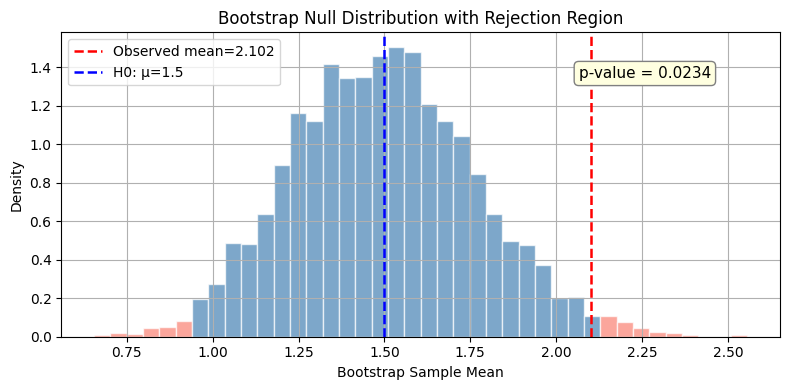

In [13]:
# C3 (7 pts): Visualise the bootstrap test.
#
# Plot histogram of boot_means (40 bins, density=True).
# Add:
#   - Vertical red dashed line at observed_mean (label: 'Observed mean')
#   - Vertical blue dashed line at mu_0_raw (label: 'H0: mu=1.5')
#   - Shade the rejection region: bars where |boot_mean - mu_0| >= |observed_mean - mu_0|
#     (hint: colour bars red where they fall in the tail)
#   - Annotate: f'p-value = {p_value:.4f}'
# Title: 'Bootstrap Null Distribution with Rejection Region'
# Label axes. Add legend. Grid.

# YOUR CODE HERE
print("=== C3 ===")
plt.figure(figsize=(8, 4))
counts, bin_edges, patches = plt.hist(boot_means, bins=40, density=True,
                                       color='steelblue', edgecolor='white', alpha=0.7)
threshold = np.abs(observed_mean - mu_0_raw)
for patch, left_edge in zip(patches, bin_edges[:-1]):
    if abs(left_edge - mu_0_raw) >= threshold:
        patch.set_facecolor('salmon')
plt.axvline(observed_mean, color='red', linestyle='--', linewidth=1.8, label=f'Observed mean={observed_mean:.3f}')
plt.axvline(mu_0_raw, color='blue', linestyle='--', linewidth=1.8, label=f'H0: μ={mu_0_raw}')
plt.annotate(f'p-value = {p_value:.4f}', xy=(0.72, 0.85), xycoords='axes fraction', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))
plt.xlabel('Bootstrap Sample Mean'); plt.ylabel('Density')
plt.title('Bootstrap Null Distribution with Rejection Region')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('c3_boot.png', dpi=80); plt.show()


---
### PART D — ML Connection (15 pts)

=== D1 ===
  Observed accuracy: 0.8650
  95% Bootstrap CI: (0.8150, 0.9100)


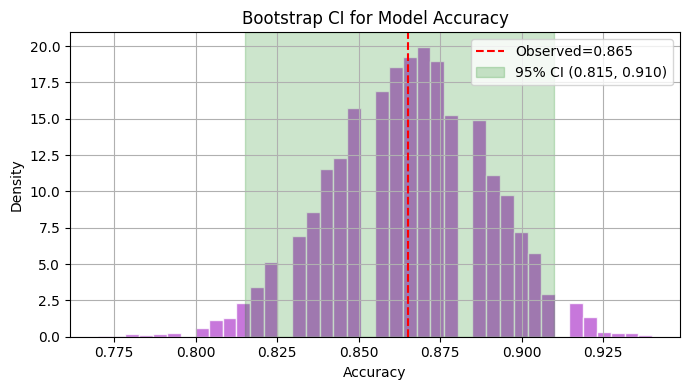

In [14]:
# D1 (8 pts): Bootstrap CI for model accuracy.
#
# Simulate model predictions on 200 test samples:
#   np.random.seed(55)
#   y_true = np.ones(200, dtype=int)         ← all positives
#   y_pred = np.random.binomial(1, 0.84, 200) ← model correct 84% of the time
#   correct = (y_true == y_pred).astype(float) ← 1 if correct, 0 if wrong
#
# Step 1: Compute observed accuracy = correct.mean()
# Step 2: Bootstrap 5000 samples of size 200 (replace=True) from correct
#          Compute mean of each → boot_acc array
#          np.random.seed(200) before the loop
# Step 3: Compute 95% CI from boot_acc using the 2.5th and 97.5th percentiles
#          (this is the percentile bootstrap CI — no formula needed)
# Step 4: Print: observed accuracy, 95% CI lower, 95% CI upper
# Step 5: Plot histogram of boot_acc with CI shaded
#          Mark observed accuracy. Title: 'Bootstrap CI for Model Accuracy'

# YOUR CODE HERE
print("=== D1 ===")
np.random.seed(55)
y_true  = np.ones(200, dtype=int)
y_pred  = np.random.binomial(1, 0.84, 200)
correct = (y_true == y_pred).astype(float)
obs_acc = correct.mean()
print(f"  Observed accuracy: {obs_acc:.4f}")
np.random.seed(200)
boot_acc = np.array([np.random.choice(correct, size=200, replace=True).mean()
                      for _ in range(5000)])
ci95_lo = np.percentile(boot_acc, 2.5)
ci95_hi = np.percentile(boot_acc, 97.5)
print(f"  95% Bootstrap CI: ({ci95_lo:.4f}, {ci95_hi:.4f})")
plt.figure(figsize=(7, 4))
plt.hist(boot_acc, bins=40, density=True, color='mediumorchid', edgecolor='white', alpha=0.8)
plt.axvline(obs_acc, color='red', linestyle='--', label=f'Observed={obs_acc:.3f}')
plt.axvspan(ci95_lo, ci95_hi, alpha=0.2, color='green', label=f'95% CI ({ci95_lo:.3f}, {ci95_hi:.3f})')
plt.xlabel('Accuracy'); plt.ylabel('Density')
plt.title('Bootstrap CI for Model Accuracy')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('d1_acc.png', dpi=80); plt.show()


=== D2 ===
       n |       SE |  CI Width
  ----------------------------
      50 |   0.0483 |    0.1894
     100 |   0.0342 |    0.1340
     200 |   0.0242 |    0.0947
     500 |   0.0153 |    0.0599
    1000 |   0.0108 |    0.0424
  CI width < 0.05 first achieved at n = 1000


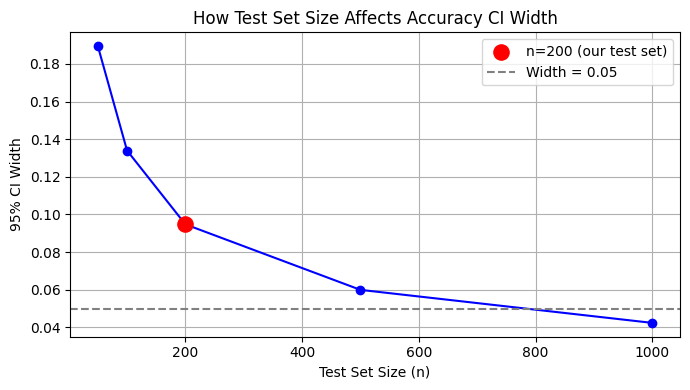

In [15]:
# D2 (7 pts): Sample size effect on CI width.
#
# Using the same 84% accuracy model, compute the 95% CI width for
# test set sizes: n = [50, 100, 200, 500, 1000]
# Use the CLT formula: CI_width = 2 × 1.96 × SE = 2 × 1.96 × (s / √n)
# where s = std of correct array (use n=200 sample's std as s estimate).
#
# Print table: n | SE | CI_width
# Plot: CI width vs n (line plot). Mark the n=200 point.
# Title: 'How Test Set Size Affects Accuracy CI Width'
# In a comment: at what n does the CI width drop below 0.05 (±2.5%)?

# YOUR CODE HERE
print("=== D2 ===")
s_est = correct.std()
n_vals = [50, 100, 200, 500, 1000]
print(f"  {'n':>6} | {'SE':>8} | {'CI Width':>9}")
print(f"  {'-'*28}")
widths = []
for n_val in n_vals:
    se_v = s_est / np.sqrt(n_val)
    w_v  = 2 * 1.96 * se_v
    widths.append(w_v)
    print(f"  {n_val:>6} | {se_v:>8.4f} | {w_v:>9.4f}")
# Find where width < 0.05
n_thresh = next((n for n, w in zip(n_vals, widths) if w < 0.05), '>1000')
print(f"  CI width < 0.05 first achieved at n = {n_thresh}")
plt.figure(figsize=(7, 4))
plt.plot(n_vals, widths, 'b-o', markersize=6)
plt.scatter([200], [widths[n_vals.index(200)]], color='red', s=120, zorder=5, label='n=200 (our test set)')
plt.axhline(0.05, color='gray', linestyle='--', label='Width = 0.05')
plt.xlabel('Test Set Size (n)'); plt.ylabel('95% CI Width')
plt.title('How Test Set Size Affects Accuracy CI Width')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('d2_width.png', dpi=80); plt.show()


---
### D3 ★ Bonus — CLT Failure Case (10 pts)

=== D3★ BONUS ===
  Cauchy sample means std: 21.07  (should be huge/unstable)
  Exponential sample means std: 0.3577  (stable, ≈ SE)


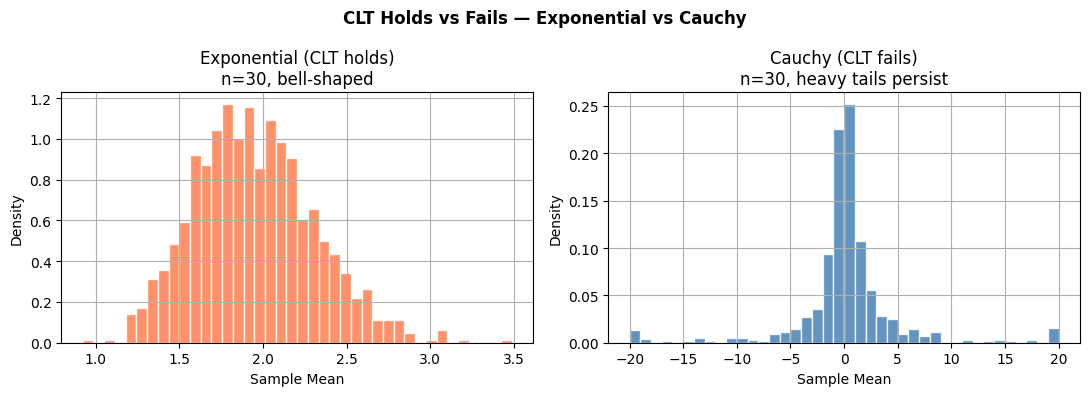

In [16]:
# D3★ BONUS (10 pts): Show when CLT breaks down.
#
# Use a Cauchy distribution — it has no finite mean or variance,
# so CLT does NOT apply.
#
# np.random.seed(42)
# cauchy_pop = np.random.standard_cauchy(size=10_000)
# Clip to [-50, 50] for plotting: cauchy_clip = np.clip(cauchy_pop, -50, 50)
#
# Simulate 1000 sample means with n=30 from cauchy_pop (replace=True)
# np.random.seed(0) before the loop
#
# Plot side-by-side:
#   Left:  sampling distribution of means from exponential pop (reuse A2 result)
#   Right: sampling distribution of means from Cauchy pop
# Observe: the Cauchy means do NOT form a bell curve — heavy tails persist
#
# Print: std of cauchy sample means (should be very large, unstable)
# Explain in a markdown cell: WHY does CLT fail for Cauchy?
# (Hint: think about what CLT requires from the population)

# YOUR CODE HERE
print("=== D3★ BONUS ===")
np.random.seed(42)
cauchy_pop  = np.random.standard_cauchy(size=10_000)
np.random.seed(0)
cauchy_means = np.array([np.random.choice(cauchy_pop, size=30, replace=True).mean()
                          for _ in range(1000)])
print(f"  Cauchy sample means std: {cauchy_means.std():.2f}  (should be huge/unstable)")
print(f"  Exponential sample means std: {sample_means.std():.4f}  (stable, ≈ SE)")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sample_means, bins=40, density=True, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title('Exponential (CLT holds)\nn=30, bell-shaped')
axes[0].set_xlabel('Sample Mean'); axes[0].set_ylabel('Density'); axes[0].grid(True)
cauchy_clip = np.clip(cauchy_means, -20, 20)
axes[1].hist(cauchy_clip, bins=40, density=True, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Cauchy (CLT fails)\nn=30, heavy tails persist')
axes[1].set_xlabel('Sample Mean'); axes[1].set_ylabel('Density'); axes[1].grid(True)
fig.suptitle('CLT Holds vs Fails — Exponential vs Cauchy', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('d3_cauchy.png', dpi=80); plt.show()

**D3★ Explanation — Why Does CLT Fail for Cauchy?**

> The Cauchy distribution has no finite mean and no finite variance. The CLT requires the population to have a finite variance (and mean) so that the sampling distribution of the sample mean converges to a normal distribution. Because the Cauchy distribution’s variance is infinite, the sample means do not average out the extreme values; heavy tails persist even for large n, and the sampling distribution remains Cauchy-like, not normal.

---
## 🏆 SECTION 4 — Scoring Rubric

| Part | Task | Points | What's Checked |
|------|------|--------|----------------|
| A | A1 — population description | 5 | mean, std, min, max, median, skewness (manual formula); histogram |
| A | A2 — CLT simulation n=30 | 7 | 1000 sample means; mean≈μ; std≈SE; % error; histogram |
| A | A3 — CLT across sample sizes | 8 | Table for all 4 n values; 2×2 subplot grid; SE converging |
| A | A4 — written verification | 5 | Q1, Q2, Q3 answered; ratio computed and matches theory |
| **A Total** | | **25** | |
| B | B1 — 95% CI for sample_raw | 5 | SE correct; CI formula correct; coverage check printed |
| B | B2 — 3 confidence levels | 5 | Table with all 3 levels; widths increase with confidence |
| B | B3 — empirical coverage | 5 | ~95% coverage printed; hlines plot (green/red) with μ line |
| B | B4 — written client response | 5 | Number + Reason + Action; references CI calculation |
| **B Total** | | **20** | |
| C | C1 — H0 setup + shift | 5 | observed_mean computed; shifted mean ≈ mu_0_raw verified |
| C | C2 — bootstrap p-value | 8 | 5000 bootstrap; p-value correct; decision + English explanation |
| C | C3 — visualisation | 7 | Histogram + rejection region shaded + observed/H0 lines + p-value annotation |
| **C Total** | | **20** | |
| D | D1 — bootstrap CI for accuracy | 8 | Percentile CI computed; histogram with CI shaded |
| D | D2 — sample size vs CI width | 7 | Table for 5 n values; plot; threshold n identified |
| **D Total** | | **15** | |
| D3★ | CLT failure — Cauchy | 10 | Cauchy means simulated; side-by-side plot; markdown explanation correct |
| **GRAND TOTAL** | | **80 (+10★)** | |

---

## 🎤 Interview Framing

*"Your model got 84% accuracy on the test set. How confident are you in that number?"*

**Your answer should be:**  
"Accuracy is a sample statistic — it has a standard error like any other mean. For n=200, SE ≈ 0.026, so the 95% CI is roughly 84% ± 5%. That means if I retested with a different random sample of 200, the true accuracy would fall in that range 95% of the time. If the client needs a tighter estimate — say, ±2% — I'd need about 1,400 test samples. I always report accuracy with its CI, not as a bare number."

---

## 📁 GitHub Note

Math Bridge is complete. Push all three days together now:  
```
git add Day63_Matrices_NumPy.ipynb Day64_Gradients.ipynb Day65_CLT.ipynb
git commit -m "Add math bridge: matrices, gradients, CLT"
git push
```
→ `Month3-Python-Portfolio` on `deepanshu0110`

This is the trio that separates "I know how to call sklearn" from "I understand why it works." That's the signal MSc admissions and senior DS roles are looking for.